# Индивидуальная работа 1
## Статистический анализ пользовательских рецензий на игры серии Resident Evil

**Студент:** Оксана Годорожа  
**Источник данных:** Kaggle — Resident Evil Reviews Dataset (Metacritic)  
**Инструмент:** Python 3, Jupyter Notebook


## I. Введение

**Цель анализа:** исследовать структуру пользовательских оценок и тональности отзывов на игры серии Resident Evil, выявить статистические закономерности и проверить гипотезы о связи между числовыми оценками и характеристиками текста отзывов.

**Статистические задачи:**
1. Описать распределение оценок, тональности и субъективности отзывов
2. Построить доверительные интервалы для средней оценки и доли позитивных отзывов
3. Проверить, различается ли средняя оценка между группами высокой и низкой тональности (t-тест)
4. Проверить зависимость между тональностью и субъективностью отзывов (χ²)
5. Проверить различие средней тональности между группами оценок (ANOVA)

**Описание набора данных:**

| Переменная | Тип | Описание |
|---|---|---|
| `score` | Числовая | Оценка пользователя (0–10) |
| `sentiment` | Числовая | Тональность текста (от −1 до +1) |
| `subjectivity` | Числовая | Субъективность текста (0–1) |
| `review_length` | Числовая | Длина отзыва (количество слов) |
| `score_category` | Категориальная | Категория оценки (Negative/Neutral/Positive) |
| `sentiment_category` | Категориальная | Категория тональности (Negative/Neutral/Positive) |
| `subjectivity_category` | Категориальная | Субъективность (Objective/Subjective) |

> **Источник:** Kaggle, датасет `jagpreet796/resident-evil`, 182 отзыва с Metacritic


## Загрузка библиотек и данных

In [5]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import shapiro, levene, f_oneway, chi2_contingency, ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)

df_raw = pd.read_csv('residentevil.csv', header=None)
df = df_raw.iloc[1:].copy()
df.columns = ['index', 'username', 'score', 'review', 'sentiment', 'subjectivity']
df = df.reset_index(drop=True)

df['score']        = pd.to_numeric(df['score'], errors='coerce')
df['sentiment']    = pd.to_numeric(df['sentiment'], errors='coerce')
df['subjectivity'] = pd.to_numeric(df['subjectivity'], errors='coerce')

df['review_length'] = df['review'].apply(lambda x: len(str(x).split()))

df['score_category']        = df['score'].apply(lambda s: 'Negative' if s<=5 else ('Neutral' if s<=8 else 'Positive'))
df['sentiment_category']    = df['sentiment'].apply(lambda s: 'Negative' if s<-0.05 else ('Neutral' if s<=0.05 else 'Positive'))
df['subjectivity_category'] = df['subjectivity'].apply(lambda s: 'Objective' if s<0.5 else 'Subjective')
df['score_group']           = df['score'].apply(lambda x: '1-7' if x<=7 else ('8' if x==8 else ('9' if x==9 else '10')))

print(f"Датасет загружен: {df.shape[0]} отзывов, {df.shape[1]} переменных")
df[['username','score','sentiment','subjectivity','review_length']].head()


Датасет загружен: 182 отзывов, 11 переменных


,username,score,sentiment,subjectivity,review_length
0,Izgar,9,-0.081250,0.683333,17
1,Vmac19,6,0.215000,0.490000,42
2,TomNX,9,-0.400000,0.400000,10
3,Diniandra,9,0.655556,0.638889,15
4,Radzz202,10,0.040625,0.675000,55


## II. Описательный анализ и визуализация
### 2.1 Описательные статистики числовых переменных

In [6]:
desc = df[['score','sentiment','subjectivity','review_length']].agg(['mean','median','std','min','max']).round(4)
desc.index = ['Среднее','Медиана','Ст. отклонение','Минимум','Максимум']
desc


,score,sentiment,subjectivity,review_length
Среднее,9.4835,0.0647,0.5863,112.3462
Медиана,10.0000,0.1000,0.5712,53.5000
Ст. отклонение,1.3532,0.2889,0.1529,154.0133
Минимум,1.0000,-1.0000,0.2533,10.0000
Максимум,10.0000,0.9250,1.0000,943.0000


### 2.2 Частоты категориальных переменных

In [7]:
for col in ['score_category','sentiment_category','subjectivity_category']:
    freq = df[col].value_counts()
    prop = (df[col].value_counts(normalize=True)*100).round(2)
    print(f"\n{'='*45}\n  {col}\n{'='*45}")
    print(pd.DataFrame({'Количество':freq,'Процент (%)':prop}))



  score_category
                Количество  Процент (%)
score_category                         
Positive               171        93.96
Neutral                  6         3.30
Negative                 5         2.75

  sentiment_category
                    Количество  Процент (%)
sentiment_category                         
Positive                   109        59.89
Negative                    39        21.43
Neutral                     34        18.68

  subjectivity_category
                       Количество  Процент (%)
subjectivity_category                         
Subjective                    130        71.43
Objective                      52        28.57


### 2.3 Визуализация: гистограммы

Гистограммы показывают распределение трёх ключевых числовых переменных.

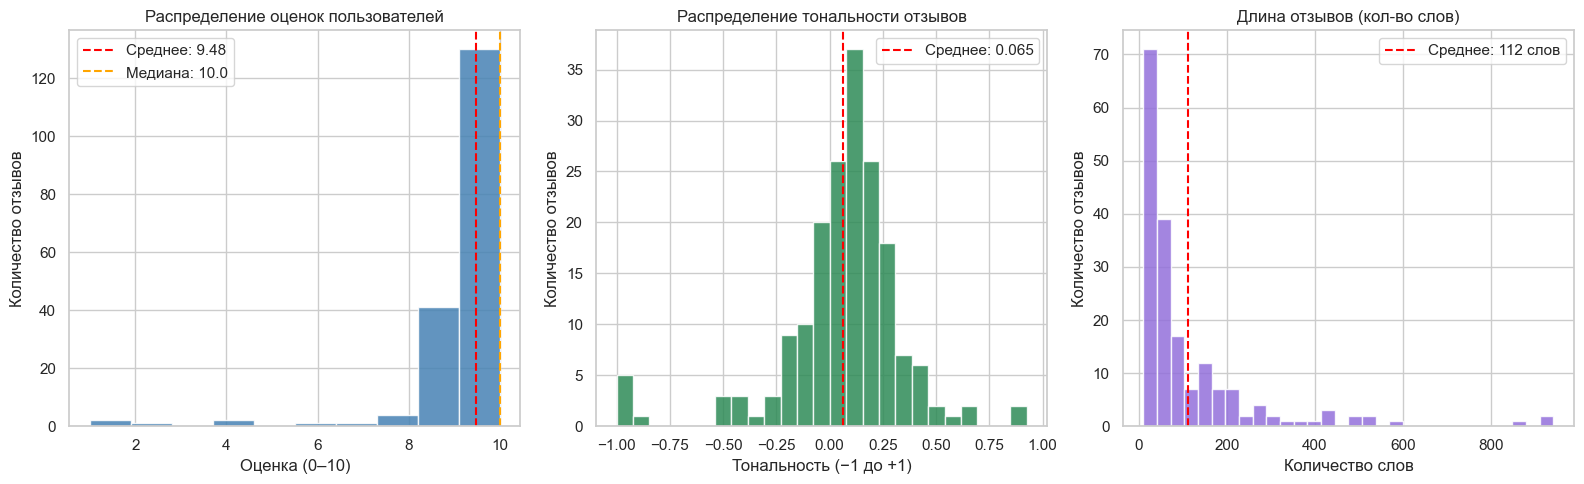


Интерпретация:
- Оценки: сильная левосторонняя асимметрия — 93.96% отзывов имеют оценку 9-10.
  Медиана (10) > среднего (9.48) не соблюдается, но пик у 10.
- Тональность: приблизительно симметричное распределение около 0,
  с небольшим смещением в положительную сторону (среднее=0.065).
- Длина: сильная правосторонняя асимметрия — большинство отзывов
  короткие (до 50 слов), редкие достигают 943 слов.



In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(df['score'], bins=10, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['score'].mean(),   color='red',    linestyle='--', label=f"Среднее: {df['score'].mean():.2f}")
axes[0].axvline(df['score'].median(), color='orange', linestyle='--', label=f"Медиана: {df['score'].median():.1f}")
axes[0].set_title('Распределение оценок пользователей')
axes[0].set_xlabel('Оценка (0–10)')
axes[0].set_ylabel('Количество отзывов')
axes[0].legend()


axes[1].hist(df['sentiment'], bins=25, color='seagreen', edgecolor='white', alpha=0.85)
axes[1].axvline(df['sentiment'].mean(), color='red', linestyle='--', label=f"Среднее: {df['sentiment'].mean():.3f}")
axes[1].set_title('Распределение тональности отзывов')
axes[1].set_xlabel('Тональность (−1 до +1)')
axes[1].set_ylabel('Количество отзывов')
axes[1].legend()

axes[2].hist(df['review_length'], bins=30, color='mediumpurple', edgecolor='white', alpha=0.85)
axes[2].axvline(df['review_length'].mean(), color='red', linestyle='--', label=f"Среднее: {df['review_length'].mean():.0f} слов")
axes[2].set_title('Длина отзывов (кол-во слов)')
axes[2].set_xlabel('Количество слов')
axes[2].set_ylabel('Количество отзывов')
axes[2].legend()

plt.tight_layout()
plt.savefig('fig1_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print("""
Интерпретация:
- Оценки: сильная левосторонняя асимметрия — 93.96% отзывов имеют оценку 9-10.
  Медиана (10) > среднего (9.48) не соблюдается, но пик у 10.
- Тональность: приблизительно симметричное распределение около 0,
  с небольшим смещением в положительную сторону (среднее=0.065).
- Длина: сильная правосторонняя асимметрия — большинство отзывов
  короткие (до 50 слов), редкие достигают 943 слов.
""")


### 2.4 Boxplot и столбчатые диаграммы

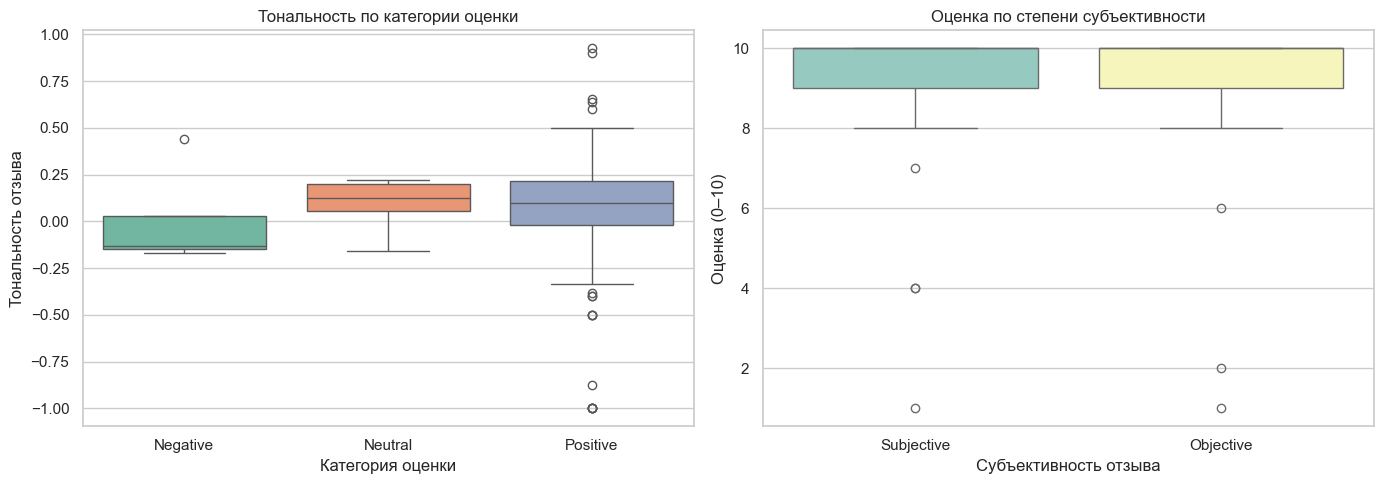


Интерпретация:
- Тональность отзывов с негативными оценками (Negative) имеет больший разброс
  и смещена в отрицательную сторону по сравнению с позитивными.
- Субъективные отзывы не имеют явного преимущества в оценках —
  объективные отзывы дают схожие оценки, что говорит о независимости переменных.



In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='score_category', y='sentiment',
            order=['Negative','Neutral','Positive'], ax=axes[0], palette='Set2')
axes[0].set_title('Тональность по категории оценки')
axes[0].set_xlabel('Категория оценки')
axes[0].set_ylabel('Тональность отзыва')

sns.boxplot(data=df, x='subjectivity_category', y='score', ax=axes[1], palette='Set3')
axes[1].set_title('Оценка по степени субъективности')
axes[1].set_xlabel('Субъективность отзыва')
axes[1].set_ylabel('Оценка (0–10)')

plt.tight_layout()
plt.savefig('fig2_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("""
Интерпретация:
- Тональность отзывов с негативными оценками (Negative) имеет больший разброс
  и смещена в отрицательную сторону по сравнению с позитивными.
- Субъективные отзывы не имеют явного преимущества в оценках —
  объективные отзывы дают схожие оценки, что говорит о независимости переменных.
""")


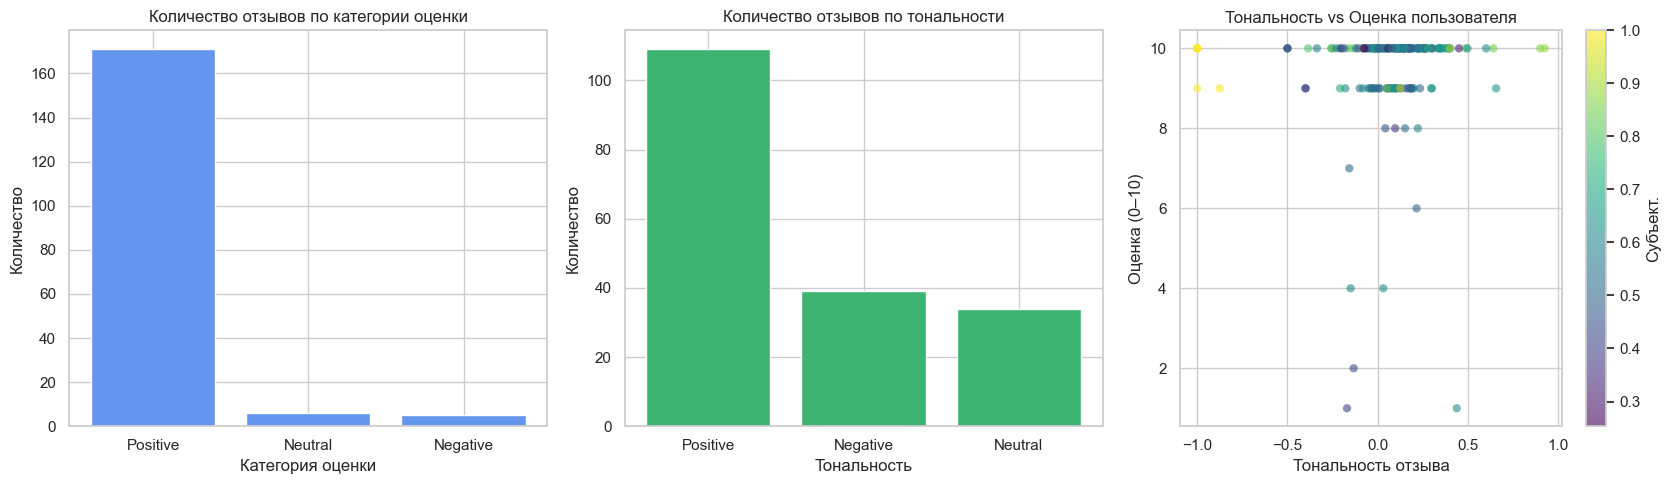


Интерпретация:
- 93.96% отзывов — позитивные (оценка 9-10), что характерно для
  фанатских рецензий на любимую серию.
- Позитивная тональность доминирует (59.89%), но 21.43% отзывов
  имеют негативную тональность несмотря на высокие оценки.
- Scatter не показывает чёткой линейной связи между тональностью
  и оценкой — игроки дают высокие оценки независимо от эмоционального тона.



In [10]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sc = df['score_category'].value_counts()
axes[0].bar(sc.index, sc.values, color='cornflowerblue', edgecolor='white')
axes[0].set_title('Количество отзывов по категории оценки')
axes[0].set_xlabel('Категория оценки')
axes[0].set_ylabel('Количество')

sm = df['sentiment_category'].value_counts()
axes[1].bar(sm.index, sm.values, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Количество отзывов по тональности')
axes[1].set_xlabel('Тональность')
axes[1].set_ylabel('Количество')

scatter = axes[2].scatter(df['sentiment'], df['score'],
                          c=df['subjectivity'], cmap='viridis', alpha=0.6, edgecolors='none')
axes[2].set_title('Тональность vs Оценка пользователя')
axes[2].set_xlabel('Тональность отзыва')
axes[2].set_ylabel('Оценка (0–10)')
plt.colorbar(scatter, ax=axes[2], label='Субъект.')

plt.tight_layout()
plt.savefig('fig3_bar_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("""
Интерпретация:
- 93.96% отзывов — позитивные (оценка 9-10), что характерно для
  фанатских рецензий на любимую серию.
- Позитивная тональность доминирует (59.89%), но 21.43% отзывов
  имеют негативную тональность несмотря на высокие оценки.
- Scatter не показывает чёткой линейной связи между тональностью
  и оценкой — игроки дают высокие оценки независимо от эмоционального тона.
""")


## III. Оценка параметров и доверительные интервалы (95%)

In [11]:
n = len(df)
score_mean = df['score'].mean()
score_std  = df['score'].std()
se_score   = score_std / np.sqrt(n)

ci_score = stats.t.interval(0.95, df=n-1, loc=score_mean, scale=se_score)

print("  ДИ для средней оценки пользователей  ")
print(f"n                  : {n}")
print(f"Выборочное среднее : {score_mean:.4f}")
print(f"Стандартная ошибка : {se_score:.4f}")
print(f"95% ДИ             : ({ci_score[0]:.4f} ; {ci_score[1]:.4f})")
print()
print("Интерпретация: С вероятностью 95% истинная средняя оценка пользователей")
print(f"игр серии RE лежит в диапазоне от {ci_score[0]:.2f} до {ci_score[1]:.2f} из 10.")

# ── ДИ для доли позитивных отзывов ──
pos_prop = (df['score_category'] == 'Positive').mean()
se_prop  = np.sqrt(pos_prop * (1 - pos_prop) / n)
ci_prop  = (pos_prop - 1.96*se_prop, pos_prop + 1.96*se_prop)

print(f"\n  ДИ для доли позитивных отзывов  ")
print(f"Выборочная доля    : {pos_prop:.4f} ({pos_prop*100:.2f}%)")
print(f"Стандартная ошибка : {se_prop:.4f}")
print(f"95% ДИ             : ({ci_prop[0]*100:.2f}% ; {ci_prop[1]*100:.2f}%)")
print()
print("Интерпретация: С вероятностью 95% истинная доля позитивных отзывов")
print(f"среди всех пользователей RE составляет от {ci_prop[0]*100:.1f}% до {ci_prop[1]*100:.1f}%.")


  ДИ для средней оценки пользователей  
n                  : 182
Выборочное среднее : 9.4835
Стандартная ошибка : 0.1003
95% ДИ             : (9.2856 ; 9.6814)

Интерпретация: С вероятностью 95% истинная средняя оценка пользователей
игр серии RE лежит в диапазоне от 9.29 до 9.68 из 10.

  ДИ для доли позитивных отзывов  
Выборочная доля    : 0.9396 (93.96%)
Стандартная ошибка : 0.0177
95% ДИ             : (90.49% ; 97.42%)

Интерпретация: С вероятностью 95% истинная доля позитивных отзывов
среди всех пользователей RE составляет от 90.5% до 97.4%.


## IV. Проверка гипотез — t-тест

**Вопрос:** Влияет ли тональность отзыва на числовую оценку игры?

- **H₀:** μ(высокая тональность) = μ(низкая тональность) — средние оценки одинаковы
- **H₁:** μ(высокая тональность) ≠ μ(низкая тональность) — средние оценки различаются
- **Уровень значимости:** α = 0,05
- **Тест:** двухвыборочный t-тест Уэлча (σ неизвестна, дисперсии могут различаться)


In [13]:
high_sent = df[df['sentiment'] > 0.1]['score']   
low_sent  = df[df['sentiment'] <= 0.1]['score']  

print(f"Группа высокой тональности : n={len(high_sent)}, среднее={high_sent.mean():.4f}")
print(f"Группа низкой тональности  : n={len(low_sent)},  среднее={low_sent.mean():.4f}")

t_stat, p_val = ttest_ind(high_sent, low_sent, equal_var=False)

print(f"\nt-статистика : {t_stat:.4f}")
print(f"p-значение   : {p_val:.6f}")

alpha = 0.05
if p_val < alpha:
    print(f"\nВывод: p={p_val:.4f} < α={alpha} → ОТВЕРГАЕМ H₀")
    print("Средние оценки статистически значимо различаются между группами.")
else:
    print(f"\nВывод: p={p_val:.4f} ≥ α={alpha} → НЕ ОТВЕРГАЕМ H₀")
    print("Нет достаточных доказательств, что тональность текста влияет на числовую оценку.")
    print("Пользователи дают высокие оценки независимо от эмоционального тона текста.")


Группа высокой тональности : n=89, среднее=9.6404
Группа низкой тональности  : n=93,  среднее=9.3333

t-статистика : 1.5470
p-значение   : 0.123743

Вывод: p=0.1237 ≥ α=0.05 → НЕ ОТВЕРГАЕМ H₀
Нет достаточных доказательств, что тональность текста влияет на числовую оценку.
Пользователи дают высокие оценки независимо от эмоционального тона текста.


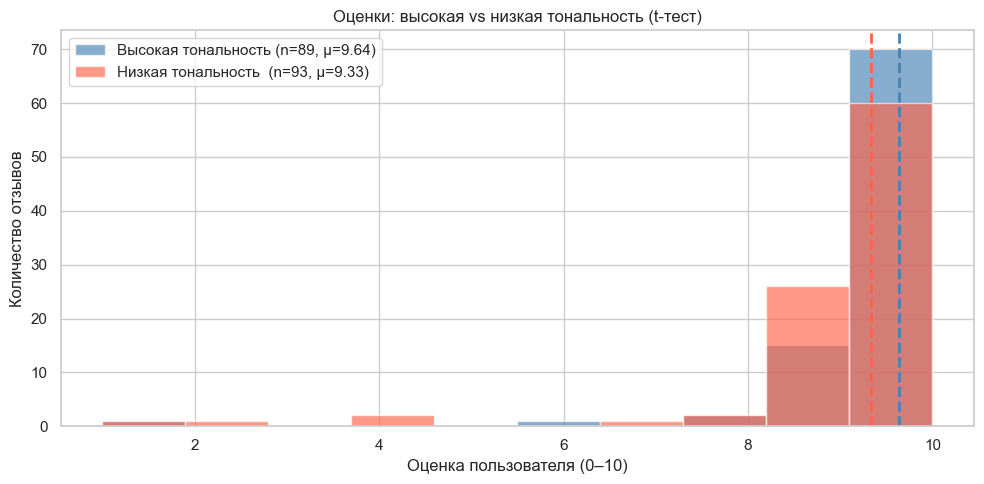

In [14]:

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(high_sent, bins=10, alpha=0.65, color='steelblue',
        label=f'Высокая тональность (n={len(high_sent)}, μ={high_sent.mean():.2f})')
ax.hist(low_sent,  bins=10, alpha=0.65, color='tomato',
        label=f'Низкая тональность  (n={len(low_sent)}, μ={low_sent.mean():.2f})')
ax.axvline(high_sent.mean(), color='steelblue', linestyle='--', linewidth=2)
ax.axvline(low_sent.mean(),  color='tomato',    linestyle='--', linewidth=2)
ax.set_title('Оценки: высокая vs низкая тональность (t-тест)')
ax.set_xlabel('Оценка пользователя (0–10)')
ax.set_ylabel('Количество отзывов')
ax.legend()
plt.tight_layout()
plt.savefig('fig4_ttest.png', dpi=150, bbox_inches='tight')
plt.show()


## V. Тест χ² для категориальных переменных

**Вопрос:** Зависит ли субъективность отзыва от его тональности?

- **H₀:** Тональность и субъективность отзыва **независимы**
- **H₁:** Между тональностью и субъективностью существует **зависимость**
- **Уровень значимости:** α = 0,05


In [15]:
ct = pd.crosstab(df['sentiment_category'], df['subjectivity_category'],
                 margins=True, margins_name='Итого')
print("Таблица сопряжённости: Тональность × Субъективность")
print(ct)


ct_no_margins = pd.crosstab(df['sentiment_category'], df['subjectivity_category'])
chi2, p_chi, dof, expected = chi2_contingency(ct_no_margins)

print(f"\nχ²-статистика  : {chi2:.4f}")
print(f"Степени свободы: {dof}")
print(f"p-значение     : {p_chi:.4f}")

alpha = 0.05
if p_chi < alpha:
    print(f"\nВывод: p={p_chi:.4f} < α={alpha} → ОТВЕРГАЕМ H₀")
    print("Тональность и субъективность отзыва статистически зависимы.")
else:
    print(f"\nВывод: p={p_chi:.4f} ≥ α={alpha} → НЕ ОТВЕРГАЕМ H₀")
    print("Нет достаточных доказательств зависимости между тональностью и субъективностью.")
    print("Субъективные и объективные отзывы распределены равномерно по тональности.")


Таблица сопряжённости: Тональность × Субъективность
subjectivity_category  Objective  Subjective  Итого
sentiment_category                                 
Negative                      12          27     39
Neutral                        5          29     34
Positive                      35          74    109
Итого                         52         130    182

χ²-статистика  : 3.9641
Степени свободы: 2
p-значение     : 0.1378

Вывод: p=0.1378 ≥ α=0.05 → НЕ ОТВЕРГАЕМ H₀
Нет достаточных доказательств зависимости между тональностью и субъективностью.
Субъективные и объективные отзывы распределены равномерно по тональности.


## VI. Дисперсионный анализ — ANOVA

**Вопрос:** Различается ли средняя тональность отзывов между группами оценок (1-7, 8, 9, 10)?

- **H₀:** μ₁₋₇ = μ₈ = μ₉ = μ₁₀ — средняя тональность одинакова для всех групп
- **H₁:** Хотя бы одна группа отличается по средней тональности
- **Обоснование ANOVA:** сравниваем более 2 групп; множественные t-тесты увеличивают ошибку I рода


In [16]:

groups = ['1-7','8','9','10']
group_data = [df[df['score_group']==g]['sentiment'].values for g in groups]


print("  Описательная статистика по группам  ")
for g, data in zip(groups, group_data):
    print(f"  Группа {g}: n={len(data)}, μ={np.mean(data):.4f}, σ={np.std(data):.4f}")


print("\n  Тест Шапиро-Уилка (нормальность)  ")
for g, data in zip(groups, group_data):
    if len(data) >= 3:
        w, p = shapiro(data)
        verdict = "✗ нарушена" if p < 0.05 else "✓ не отвергается"
        print(f"  Группа {g}: W={w:.4f}, p={p:.4f} → нормальность {verdict}")


lev_stat, lev_p = levene(*group_data)
print(f"\n  Тест Левена (однородность дисперсий)  ")
print(f"W={lev_stat:.4f}, p={lev_p:.4f}")
print("Дисперсии однородны ✓" if lev_p >= 0.05 else "Дисперсии неоднородны ✗")


f_stat, p_anova = f_oneway(*group_data)
print(f"\n  Результаты ANOVA  ")
print(f"F-статистика : {f_stat:.4f}")
print(f"p-значение   : {p_anova:.4f}")
if p_anova < 0.05:
    print("Вывод: ОТВЕРГАЕМ H₀ — средняя тональность различается между группами.")
else:
    print("Вывод: НЕ ОТВЕРГАЕМ H₀ — нет значимых различий в тональности между группами оценок.")
    print("Пользователи пишут одинаково эмоциональные отзывы независимо от того, поставили ли 9 или 10.")


  Описательная статистика по группам  
  Группа 1-7: n=7, μ=0.0103, σ=0.2177
  Группа 8: n=4, μ=0.1280, σ=0.0667
  Группа 9: n=41, μ=0.0135, σ=0.2787
  Группа 10: n=130, μ=0.0819, σ=0.2960

  Тест Шапиро-Уилка (нормальность)  
  Группа 1-7: W=0.8054, p=0.0463 → нормальность ✗ нарушена
  Группа 8: W=0.9931, p=0.9728 → нормальность ✓ не отвергается
  Группа 9: W=0.8015, p=0.0000 → нормальность ✗ нарушена
  Группа 10: W=0.8787, p=0.0000 → нормальность ✗ нарушена

  Тест Левена (однородность дисперсий)  
W=0.5845, p=0.6259
Дисперсии однородны ✓

  Результаты ANOVA  
F-статистика : 0.7271
p-значение   : 0.5371
Вывод: НЕ ОТВЕРГАЕМ H₀ — нет значимых различий в тональности между группами оценок.
Пользователи пишут одинаково эмоциональные отзывы независимо от того, поставили ли 9 или 10.


  Post-hoc анализ (Бонферрони, 6 пар)  
  1-7 vs 8: p_adj=1.0000 ✗ незначимо
  1-7 vs 9: p_adj=1.0000 ✗ незначимо
  1-7 vs 10: p_adj=1.0000 ✗ незначимо
  8 vs 9: p_adj=0.4216 ✗ незначимо
  8 vs 10: p_adj=1.0000 ✗ незначимо
  9 vs 10: p_adj=1.0000 ✗ незначимо


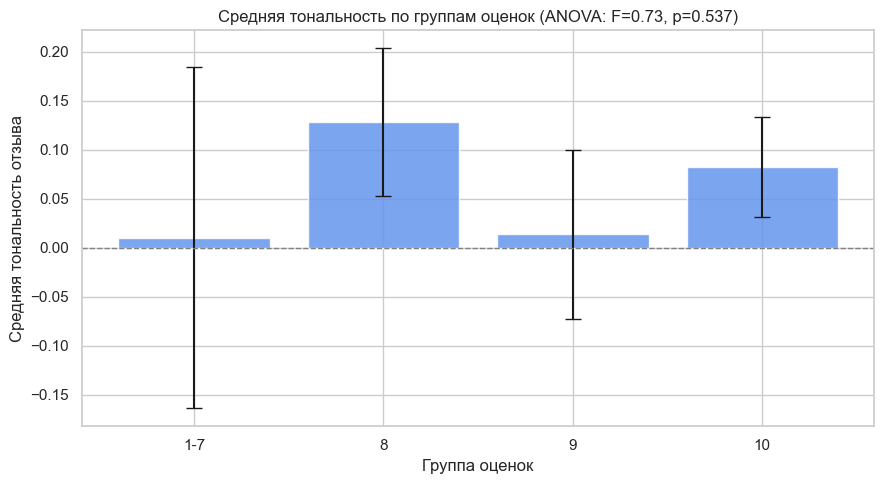

In [18]:
from itertools import combinations

pairs = list(combinations(groups, 2))
k = len(pairs)
print(f"  Post-hoc анализ (Бонферрони, {k} пар)  ")
for g1, g2 in pairs:
    a = df[df['score_group']==g1]['sentiment']
    b = df[df['score_group']==g2]['sentiment']
    if len(a)>1 and len(b)>1:
        t, p = ttest_ind(a, b, equal_var=False)
        p_adj = min(p*k, 1.0)
        sig = "✓ значимо" if p_adj < 0.05 else "✗ незначимо"
        print(f"  {g1} vs {g2}: p_adj={p_adj:.4f} {sig}")

group_stats = df.groupby('score_group')['sentiment'].agg(['mean','std','count']).loc[groups].reset_index()
group_stats['se'] = group_stats['std'] / np.sqrt(group_stats['count'])
group_stats['ci'] = 1.96 * group_stats['se']

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(group_stats['score_group'], group_stats['mean'],
       yerr=group_stats['ci'], capsize=6,
       color='cornflowerblue', edgecolor='white', alpha=0.85)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title(f'Средняя тональность по группам оценок (ANOVA: F={f_stat:.2f}, p={p_anova:.3f})')
ax.set_xlabel('Группа оценок')
ax.set_ylabel('Средняя тональность отзыва')
plt.tight_layout()
plt.savefig('fig5_anova.png', dpi=150, bbox_inches='tight')
plt.show()


## VII. Выводы и рекомендации

### Основные результаты

| Анализ | Результат | Вывод |
|---|---|---|
| Описательный | Средняя оценка = 9.48, медиана = 10 | Сильная левосторонняя асимметрия |
| ДИ для средней оценки (95%) | (9.29 ; 9.68) | Высокая точность оценки при n=182 |
| ДИ для доли позитивных (95%) | (90.49% ; 97.42%) | Подавляющее большинство довольны игрой |
| t-тест (тональность → оценка) | t=1.55, p=0.124 | **Не отвергаем H₀** — тональность не влияет на оценку |
| χ²-тест (тональность × субъективность) | χ²=3.96, p=0.138 | **Не отвергаем H₀** — переменные независимы |
| ANOVA (тональность по группам оценок) | F=0.73, p=0.537 | **Не отвергаем H₀** — тональность одинакова |
| Post-hoc (Бонферрони) | Все пары незначимы | Подтверждает результат ANOVA |

### Контекстуальная интерпретация
- Серия Resident Evil получает **исключительно высокие оценки** — 93.96% отзывов позитивные
- Интересный феномен: **тональность текста не определяет оценку** — игроки могут писать критически, но всё равно ставить 9–10, что типично для фанатских рецензий
- Субъективность отзыва не зависит от его тональности — критические и восторженные отзывы пишутся с одинаковой степенью субъективности

### Ограничения анализа
- Малый размер выборки (n=182) снижает мощность тестов, особенно для малых групп (группа «1-7»: n=7)
- Датасет несбалансирован: 71.4% позитивных оценок делает трудным сравнение групп
- Sentiment анализ выполнен автоматически (TextBlob) — точность для игровых рецензий ограничена

### Направления расширения
- Увеличить выборку, включив рецензии с других платформ (Steam, IGN)
- Применить NLP (TF-IDF, LDA) для тематического моделирования текстов
- Добавить временной анализ: как менялись оценки с течением времени
